# Figure 4: Microbial pathway expression (version 2 of the figure - replacing per taxa TPM FC)

- Putative differentially expressed pathways between cervix and vagina in CST IV and CST III
- Average log2FC from metatanscriptome (via DeSeq2)
- Per taxa contribution to each pathway element

In [1441]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import random
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from PIL import Image, ImageDraw, ImageOps

## Some constants and datafiles/preprocessing

In [1442]:
# read in tpm counts per gene and the kegg definitions
mmtm_tpms = pd.read_csv('./common/taxa_filt_mmtm_mt_virgo2_NR_Taxa_051324_junk_removed_TPMS.csv')
virgo2_kegg_defs = pd.read_csv('./common/virgo2_files/8.VIRGO2.kegg.txt', sep='\t')

mmtm_tpms = pd.merge(mmtm_tpms, virgo2_kegg_defs[['PC','KEGG']], left_on='Gene', right_on='PC', how='left').dropna().drop(columns=['PC'])

# reassign the kegg function to the first kegg function if there are multiple keggs functions assigned to the gene
mmtm_tpms['KEGG'] = mmtm_tpms['KEGG'].apply(lambda x: x.split(',')[0] if ',' in x else x)

# calculate the tpms per kegg per taxa
taxa_kegg_tpms = mmtm_tpms.groupby(['Taxa', 'KEGG']).sum(numeric_only=True).reset_index()

# rename/collapse some taxa
taxa_kegg_tpms = taxa_kegg_tpms.replace({'Taxa':{'^UBA629_sp005465875':'BVAB1', 'Gardnerella_swidsinkii':'Gardnerella_swidsinskii', 'KA00274_sp902373515':'BVAB2', '^Corynebacterium':'Corynebacterium'}}, regex=True)

# read in the metadata and create dataframes for cst IV and cst III samples
sample_csts = pd.read_csv('./fig4_datasets/mmtm_mt_cst_assingments_06122024_renamed.csv')
sample_metadata = pd.read_csv('./common/mmtm_metadata.csv')
sample_metadata = pd.merge(sample_metadata, sample_csts[['sampleID', 'CST']], left_on='IGS LABEL', right_on='sampleID', how='right').drop(columns=['IGS LABEL'])

c_samples = list(sample_metadata[sample_metadata['Cervix/Vagina'].isin(['C'])]['sampleID'].values)
v_samples = list(sample_metadata[sample_metadata['Cervix/Vagina'].isin(['V'])]['sampleID'].values)

cstIV_samples = list(sample_metadata[sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])]['sampleID'].values)
cstIV_cervix_samples = [s for s in cstIV_samples if s in c_samples]
cstIV_vagina_samples = [s for s in cstIV_samples if s in v_samples]


cstIII_samples = list(sample_metadata[sample_metadata['CST'].isin(['III'])]['sampleID'].values)
cstIII_cervix_samples = [s for s in cstIII_samples if s in c_samples]
cstIII_vagina_samples = [s for s in cstIII_samples if s in v_samples]

cols = ['Taxa', 'KEGG']
cols.extend(cstIV_cervix_samples)
cstIV_cervix_tpms = taxa_kegg_tpms[cols]

cols = ['Taxa', 'KEGG']
cols.extend(cstIV_vagina_samples)
cstIV_vagina_tpms = taxa_kegg_tpms[cols]


cols = ['Taxa', 'KEGG']
cols.extend(cstIII_cervix_samples)
cstIII_cervix_tpms = taxa_kegg_tpms[cols]

cols = ['Taxa', 'KEGG']
cols.extend(cstIII_vagina_samples)
cstIII_vagina_tpms = taxa_kegg_tpms[cols]


# read in the genes of interest and filter the tpm datasets to only include those kegg functions
target_genes = pd.read_csv('./fig4_datasets/genes_of_interest.csv')

# filter the cst IV tpms
target_keggs = []
for k in list(target_genes[target_genes['cst'] == 'IV']['kegg_ids'].values):
    target_keggs.extend(k.split(','))

cstIV_cervix_tpms = cstIV_cervix_tpms[cstIV_cervix_tpms['KEGG'].isin(target_keggs)]
curr_targets = target_genes[target_genes['cst'] == 'IV']
cstIV_cervix_tpms['label'] = cstIV_cervix_tpms['KEGG'].apply(lambda x: curr_targets[curr_targets['kegg_ids'].str.contains(x)]['gene_number_label'].values[0])

cstIV_vagina_tpms = cstIV_vagina_tpms[cstIV_vagina_tpms['KEGG'].isin(target_keggs)]
curr_targets = target_genes[target_genes['cst'] == 'IV']
cstIV_vagina_tpms['label'] = cstIV_vagina_tpms['KEGG'].apply(lambda x: curr_targets[curr_targets['kegg_ids'].str.contains(x)]['gene_number_label'].values[0])


# filter the cst III tpms 
target_keggs = []
for k in list(target_genes[target_genes['cst'] == 'III']['kegg_ids'].values):
    target_keggs.extend(k.split(','))

cstIII_cervix_tpms = cstIII_cervix_tpms[cstIII_cervix_tpms['KEGG'].isin(target_keggs)]
curr_targets = target_genes[target_genes['cst'] == 'III']
cstIII_cervix_tpms['label'] = cstIII_cervix_tpms['KEGG'].apply(lambda x: curr_targets[curr_targets['kegg_ids'].str.contains(x)]['gene_number_label'].values[0])

cstIII_vagina_tpms = cstIII_vagina_tpms[cstIII_vagina_tpms['KEGG'].isin(target_keggs)]
curr_targets = target_genes[target_genes['cst'] == 'III']
cstIII_vagina_tpms['label'] = cstIII_vagina_tpms['KEGG'].apply(lambda x: curr_targets[curr_targets['kegg_ids'].str.contains(x)]['gene_number_label'].values[0])

# sum the tpms per label per taxa
cstIV_cervix_tpms = cstIV_cervix_tpms.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()
cstIV_vagina_tpms = cstIV_vagina_tpms.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()

cstIII_cervix_tpms = cstIII_cervix_tpms.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()
cstIII_vagina_tpms = cstIII_vagina_tpms.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()

# average the tpms per taxa per label
cstIV_cervix_tpms['avg'] = cstIV_cervix_tpms.iloc[:, 2:].mean(axis=1)
cstIV_cervix_tpms = cstIV_cervix_tpms[['Taxa', 'label', 'avg']]
cstIV_cervix_tpms = cstIV_cervix_tpms.sort_values(by='label')

cstIV_vagina_tpms['avg'] = cstIV_vagina_tpms.iloc[:, 2:].mean(axis=1)
cstIV_vagina_tpms = cstIV_vagina_tpms[['Taxa', 'label', 'avg']]
cstIV_vagina_tpms = cstIV_vagina_tpms.sort_values(by='label')

cstIII_cervix_tpms['avg'] = cstIII_cervix_tpms.iloc[:, 2:].mean(axis=1)
cstIII_cervix_tpms = cstIII_cervix_tpms[['Taxa', 'label', 'avg']]
cstIII_cervix_tpms = cstIII_cervix_tpms.sort_values(by='label')

cstIII_vagina_tpms['avg'] = cstIII_vagina_tpms.iloc[:, 2:].mean(axis=1)
cstIII_vagina_tpms = cstIII_vagina_tpms[['Taxa', 'label', 'avg']]
cstIII_vagina_tpms = cstIII_vagina_tpms.sort_values(by='label')


In [1443]:
#set up taxa color scheme
taxa_key = pd.read_csv('./common/VIRGO2_taxaKey.csv')  
taxa_color_scheme = dict(zip(taxa_key.Taxa,taxa_key.Color))
taxa_text_legend = dict(zip(taxa_key.Taxa,taxa_key.Text))

def get_color(taxa):

    chars = '0123456789ABCDEF'
    taxa_color = taxa_color_scheme['other']

    if taxa in taxa_color_scheme:
        
        taxa_color = taxa_color_scheme[taxa]

    else:
        taxa_color_scheme[taxa] = '#'+''.join(random.sample(chars,6))
        #taxa_color = taxa_color_scheme[taxa]
        #taxa_color = taxa_color_scheme['other']

    get_label(taxa)
    taxa_color = taxa_color_scheme[taxa]
    return taxa_color

def get_label(taxa):
    taxa_text = 'other'
    if taxa in taxa_text_legend:
        
        if taxa == 'other':
            return taxa_text_legend[taxa]
        
        taxa_text = "$\it{%s}$" % (taxa_text_legend[taxa])

    else:
        if '_' in taxa:
            s1 = taxa.split('_')[0][0]
            s2 = taxa.split('_')[-1]
            s = s1 + '.' + s2
        else:
            s = taxa
        taxa_text_legend[taxa] = s
        taxa_text = "$\it{%s}$" % (taxa_text_legend[taxa])
        
    return taxa_text

## Make Figure Layout

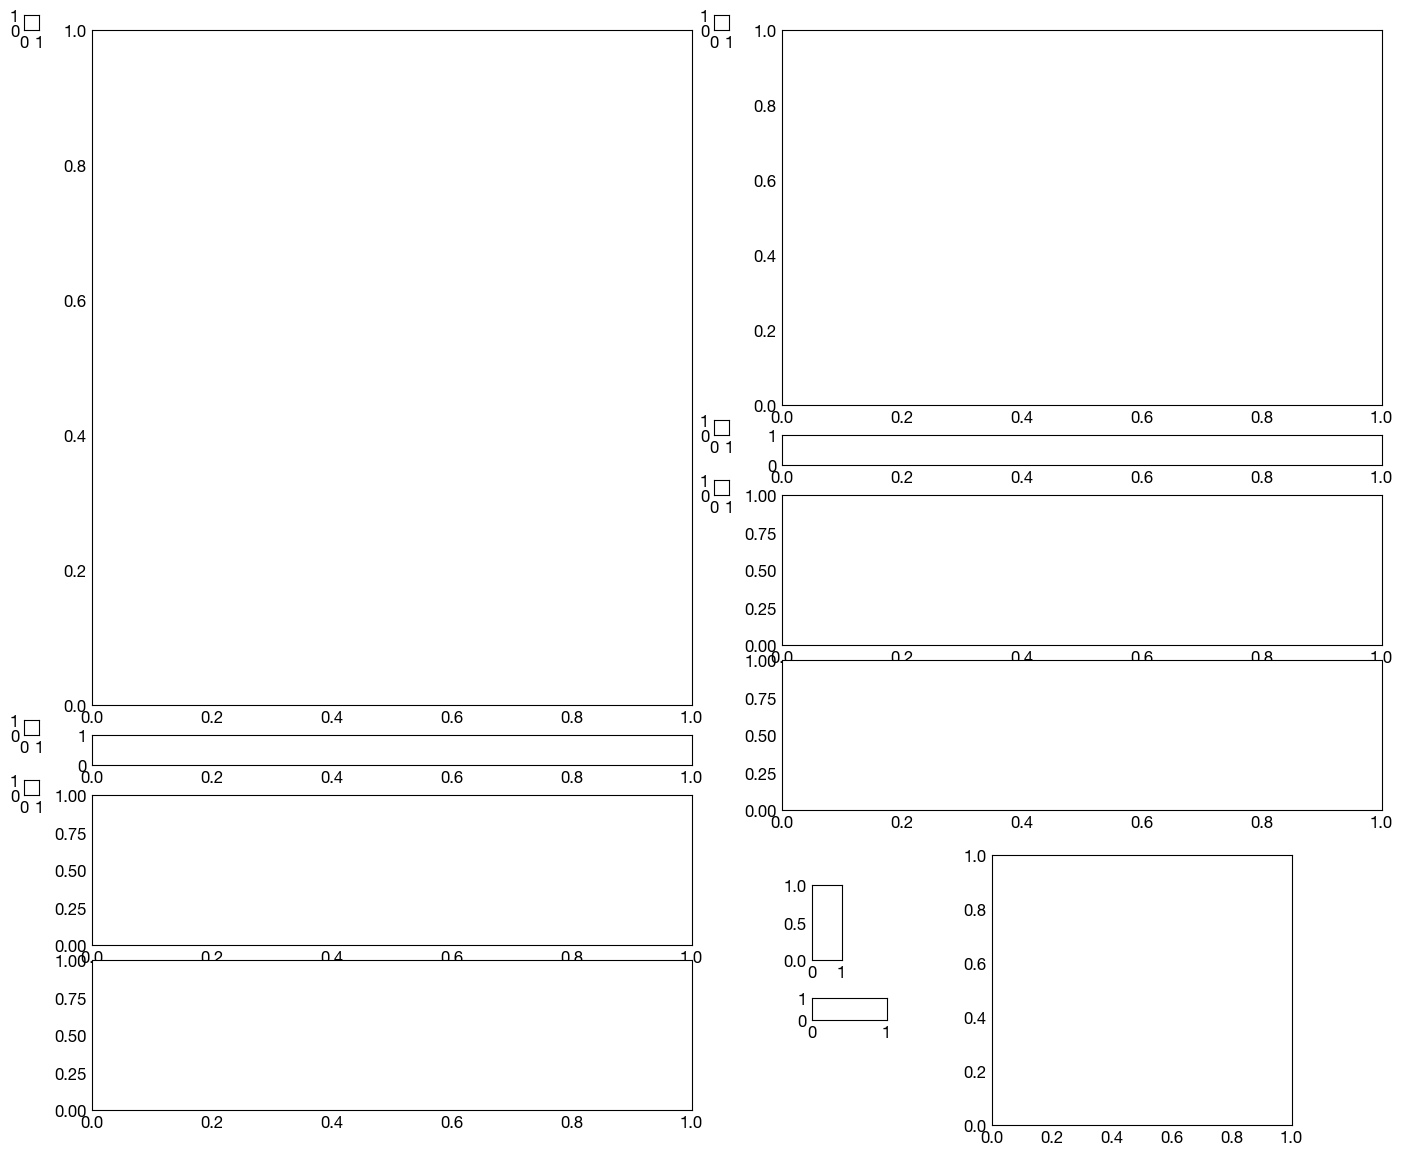

In [1444]:
# figure size
WIDTH = 15
HEIGHT = 15

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))


### add the axes

ax1 = fig.add_axes([0.05, 0.55, 0.40, 0.45])
ax2 = fig.add_axes([0.05, 0.51, 0.40, 0.02]) 
ax3_cervix = fig.add_axes([0.05, 0.39, 0.40, 0.1])
ax3_vagina = fig.add_axes([0.05, 0.28, 0.40, 0.1])

ax4 = fig.add_axes([0.51, 0.75, 0.40, 0.25])
ax5 = fig.add_axes([0.51, 0.71, 0.40, 0.02]) 
ax6_cervix = fig.add_axes([0.51, 0.59, 0.40, 0.1])
ax6_vagina = fig.add_axes([0.51, 0.48, 0.40, 0.1])

taxa_leg_ax = fig.add_axes([0.65, 0.27, 0.20, 0.18])
dot_size_leg_ax = fig.add_axes([0.53, 0.34, 0.05, 0.015])
bodysite_leg_ax = fig.add_axes([0.53, 0.38, 0.02, 0.05])


# axes for figure labels
a_ax = fig.add_axes([0.005, 1, 0.01, 0.01])
b_ax = fig.add_axes([0.005, 0.53, 0.01, 0.01])
c_ax = fig.add_axes([0.005, 0.49, 0.01, 0.01])

d_ax = fig.add_axes([0.465, 1, 0.01, 0.01])
e_ax = fig.add_axes([0.465, 0.73, 0.01, 0.01])
f_ax = fig.add_axes([0.465, 0.69, 0.01, 0.01])


## Add the pathay figures

In [1445]:
# cst IV
path_fig = Image.open('./fig4_datasets/mmtm_fig4_1.png')
ax1.imshow(np.array(path_fig))
ax1.set_axis_off()


# cst III
path_fig = Image.open('./fig4_datasets/mmtm_fig4_2.png')
ax4.imshow(np.array(path_fig))
ax4.set_axis_off()


## DeSeq2 Fold Changes

In [1446]:
cervix_color = (237, 106, 90)
vagina_color = (244, 241, 187)
def get_fc_heatmap_color(value, value_min=-2.5, value_max=2.5, color_min=vagina_color, color_max=cervix_color):
    normalized_value = (value - value_min) / (value_max - value_min)
    
    # Clamp normalized value to [0, 1] to avoid out-of-bounds errors
    normalized_value = max(0, min(1, normalized_value))
    
    # Interpolate each color channel (RGB)
    r = int(color_min[0] + (color_max[0] - color_min[0]) * normalized_value)
    g = int(color_min[1] + (color_max[1] - color_min[1]) * normalized_value)
    b = int(color_min[2] + (color_max[2] - color_min[2]) * normalized_value)
    
    # Convert to hex format
    return f"#{r:02x}{g:02x}{b:02x}"

my_cv_cmap = matplotlib.colors.ListedColormap(['#5924ed','#9fafe0'])
bodysite_colors = {'Cervix': '#5924ed', 'Vagina': '#9fafe0'}
get_bs_color = lambda x: bodysite_colors['Cervix'] if x > 0 else bodysite_colors['Vagina']
get_size = lambda x: 5*abs(x)


In [1447]:
# cst IV
target_keggs = []
for k in list(target_genes[target_genes['cst'] == 'IV']['kegg_ids'].values):
    target_keggs.extend(k.split(','))

# read in deqseq results
dek = pd.read_csv('./fig4_datasets/mmtm_mt_diff_micro_kegg_cervix-vagina_cstIV_deseq2.csv')
dek['row'] = dek['row'].apply(lambda x: x.split(',')[0])
dek = dek[dek['row'].isin(target_keggs)]
curr_targets = target_genes[target_genes['cst'] == 'IV']
dek['label'] = dek['row'].apply(lambda x: curr_targets[curr_targets['kegg_ids'].str.contains(x)]['gene_number_label'].values[0])

# get the average log2FC for each label
label_avg_fc = dek[['label', 'log2FoldChange']].groupby('label').apply(lambda x: x.loc[x['log2FoldChange'].abs().idxmax()]).reset_index(drop=True)
label_avg_fc['label'] = label_avg_fc['label'].astype(int).astype(str)
#sns.barplot(data=label_avg_fc, x='label', y='log2FoldChange', ax=ax2, color='black', width=0.5)

tick_labels = sorted(label_avg_fc['label'].astype(int).unique())
loc = 1
for i, row in label_avg_fc.iterrows():
    #ax2.bar(x=loc, bottom=0, height=1, width=1, color=get_fc_heatmap_color(row['log2FoldChange']))
    ax2.plot([loc], [0.5], marker='o', markersize=get_size(row['log2FoldChange']), color=get_bs_color(row['log2FoldChange']))
    loc += 1
ax2.set_xbound([0.625,len(tick_labels)+0.375])
ax2.set_xticks(tick_labels)
ax2.set_xticklabels(tick_labels)
ax2.set_ylim(0,1)
ax2.set_yticklabels([])
ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax2.spines[['right', 'left', 'bottom']].set_visible(False)

# cst III
target_keggs = []
for k in list(target_genes[target_genes['cst'] == 'III']['kegg_ids'].values):
    target_keggs.extend(k.split(','))

# read in deqseq results
dek = pd.read_csv('./fig4_datasets/mmtm_mt_diff_micro_kegg_cervix-vagina_cstIII_deseq2.csv')
dek['row'] = dek['row'].apply(lambda x: x.split(',')[0])
dek = dek[dek['row'].isin(target_keggs)]
curr_targets = target_genes[target_genes['cst'] == 'III']
dek['label'] = dek['row'].apply(lambda x: curr_targets[curr_targets['kegg_ids'].str.contains(x)]['gene_number_label'].values[0])

# get the average log2FC for each label
label_avg_fc = dek[['label', 'log2FoldChange']].groupby('label').apply(lambda x: x.loc[x['log2FoldChange'].abs().idxmax()]).reset_index(drop=True)
label_avg_fc['label'] = label_avg_fc['label'].astype(int).astype(str)
#sns.barplot(data=label_avg_fc, x='label', y='log2FoldChange', ax=ax5, color='black', width=0.3)


tick_labels = sorted(label_avg_fc['label'].astype(int).unique())
loc = 1
for i, row in label_avg_fc.iterrows():
    #ax5.bar(x=loc, bottom=0, height=1, width=1, color=get_fc_heatmap_color(row['log2FoldChange']))
    ax5.plot([loc], [0.5], marker='o', markersize=get_size(row['log2FoldChange']), color=get_bs_color(row['log2FoldChange']))
    loc += 1
ax5.set_xbound([0.625,len(tick_labels)+0.375])
ax5.set_xticks(tick_labels)
ax5.set_xticklabels(tick_labels)
ax5.set_ylim(0,1)
ax5.set_yticklabels([])
ax5.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax5.spines[['right', 'left', 'bottom']].set_visible(False)




## Per Taxa Expression Contribution

In [1448]:
taxa_legend = []
min_pcent_contrib = 0.05

In [1449]:
# track the taxa to keep. only taxa that are present at the min_pcent_contrib in at least 1 sample
taxa_to_keep = []

for tpm_data in [cstIV_cervix_tpms, cstIV_vagina_tpms, cstIII_cervix_tpms, cstIII_vagina_tpms]:
    for label, data in tpm_data.groupby('label'):
        data['avg'] = data['avg']/sum(data['avg'])
        data['Taxa'] = data.apply(lambda x: 'other' if (x['avg'] < min_pcent_contrib) else x['Taxa'], axis=1)
        data['Taxa'] = data['Taxa'].replace({'MultiGenera':'other'})
        taxa_to_keep.extend(data['Taxa'])

In [1450]:
# cst IV
tick_labels = sorted(cstIV_cervix_tpms['label'].unique())

loc = 1
ax = ax3_cervix
for label, data in cstIV_cervix_tpms.groupby('label'):
    data['avg'] = data['avg']/sum(data['avg'])
    data['Taxa'] = data.apply(lambda x: 'other' if (x['Taxa'] not in taxa_to_keep) else x['Taxa'], axis=1)
    data['Taxa'] = data['Taxa'].replace({'MultiGenera':'other'})
    data = data.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()
    data = data.sort_values(by='Taxa')
    data = pd.concat([data[data['Taxa'] != 'other'], data[data['Taxa'] == 'other']])

    bottom = 0
    for i, row in data.iterrows():
        taxa = row['Taxa']
        
        #color = taxa_color_scheme[taxa]
        color = get_color(taxa)
        taxa_legend.append(taxa)
        
        val = row['avg']
        ax.bar(x=loc, width=0.75, bottom=bottom, height=val, color=color)
        bottom += val
    
    loc += 1

loc = 1
ax = ax3_vagina
for label, data in cstIV_vagina_tpms.groupby('label'):
    data['avg'] = data['avg']/sum(data['avg'])
    data['Taxa'] = data.apply(lambda x: 'other' if (x['Taxa'] not in taxa_to_keep) else x['Taxa'], axis=1)
    data['Taxa'] = data['Taxa'].replace({'MultiGenera':'other'})
    data = data.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()
    data = data.sort_values(by='Taxa')
    data = pd.concat([data[data['Taxa'] != 'other'], data[data['Taxa'] == 'other']])

    bottom = 0
    for i, row in data.iterrows():
        taxa = row['Taxa']
        
        #color = taxa_color_scheme[taxa]
        color = get_color(taxa)
        taxa_legend.append(taxa)
        
        val = row['avg']
        ax.bar(x=loc, width=0.75, bottom=bottom, height=val, color=color)
        bottom += val
    
    loc += 1

ax3_cervix.get_xaxis().set_visible(False)
ax3_vagina.set_xticks(tick_labels)
ax3_vagina.set_xticklabels(tick_labels)

for ax in [ax3_cervix, ax3_vagina]:
    ax.set_xbound([0.625,len(tick_labels)+0.375])
    ax.set_ybound([0, 1])

ax3_cervix.text(x=len(tick_labels)+0.4, y=max(ax3_cervix.get_ybound())/2, s='Cervix', rotation=-90, va='center', ha='left')
ax3_vagina.text(x=len(tick_labels)+0.4, y=max(ax3_vagina.get_ybound())/2, s='Vagina', rotation=-90, va='center', ha='left')

Text(20.4, 0.5, 'Vagina')

In [1451]:
# cst IIII

tick_labels = sorted(cstIII_cervix_tpms['label'].unique())

loc = 1
ax = ax6_cervix
for label, data in cstIII_cervix_tpms.groupby('label'):
    data['avg'] = data['avg']/sum(data['avg'])
    data['Taxa'] = data.apply(lambda x: 'other' if (x['Taxa'] not in taxa_to_keep) else x['Taxa'], axis=1)
    data['Taxa'] = data['Taxa'].replace({'MultiGenera':'other'})    
    data = data.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()
    data = data.sort_values(by='Taxa')
    data = pd.concat([data[data['Taxa'] != 'other'], data[data['Taxa'] == 'other']])

    bottom = 0
    for i, row in data.iterrows():
        taxa = row['Taxa']
        
        #color = taxa_color_scheme[taxa]
        color = get_color(taxa)
        taxa_legend.append(taxa)
        
        val = row['avg']
        ax.bar(x=loc, width=0.75, bottom=bottom, height=val, color=color)
        bottom += val
    
    loc += 1

loc = 1
ax = ax6_vagina
for label, data in cstIII_vagina_tpms.groupby('label'):
    data['avg'] = data['avg']/sum(data['avg'])
    data['Taxa'] = data.apply(lambda x: 'other' if (x['Taxa'] not in taxa_to_keep) else x['Taxa'], axis=1)
    data['Taxa'] = data['Taxa'].replace({'MultiGenera':'other'})
    data = data.groupby(['Taxa', 'label']).sum(numeric_only=True).reset_index()
    data = data.sort_values(by='Taxa')
    data = pd.concat([data[data['Taxa'] != 'other'], data[data['Taxa'] == 'other']])

    bottom = 0
    for i, row in data.iterrows():
        taxa = row['Taxa']
        
        #color = taxa_color_scheme[taxa]
        color = get_color(taxa)
        taxa_legend.append(taxa)
        
        val = row['avg']
        ax.bar(x=loc, width=0.75, bottom=bottom, height=val, color=color)
        bottom += val
    
    loc += 1

ax6_cervix.get_xaxis().set_visible(False)
ax6_vagina.set_xticks(tick_labels)
ax6_vagina.set_xticklabels(tick_labels)

for ax in [ax6_cervix, ax6_vagina]:
    ax.set_xbound([0.625,len(tick_labels)+0.375])
    ax.set_ybound([0, 1])

ax6_cervix.text(x=len(tick_labels)+0.4, y=max(ax6_cervix.get_ybound())/2, s='Cervix', rotation=-90, va='center', ha='left')
ax6_vagina.text(x=len(tick_labels)+0.4, y=max(ax6_vagina.get_ybound())/2, s='Vagina', rotation=-90, va='center', ha='left')

Text(13.4, 0.5, 'Vagina')

## Add Taxa Legend

In [1452]:
# adding functions legend
patch_list = [] 
print(taxa_legend)
taxa_legend = list(set(taxa_legend))
taxa_legend = [t if t in taxa_text_legend else 'other' for t in taxa_legend]
taxa_legend = list(set(taxa_legend))
taxa_legend = sorted(taxa_legend)
for t in taxa_legend:
    patch_list.append(mpatches.Patch(color=get_color(t),label=get_label(t)))

taxa_leg_ax.legend(handles=patch_list, ncol=3, loc=(0, 0.1), bbox_to_anchor=(0,0,1,1), fontsize=8, frameon=False)
taxa_leg_ax.set_axis_off()

['Staphylococcus_aureus', 'Staphylococcus_epidermidis', 'other', 'Berryella_sp001552935', 'Staphylococcus_aureus', 'Staphylococcus_epidermidis', 'other', 'Actinomyces_urogenitalis', 'Corynebacterium', 'Corynebacterium_imitans', 'Corynebacterium_sp001767255', 'Cutibacterium_acnes', 'Klebsiella_pneumoniae', 'Staphylococcus_aureus', 'Staphylococcus_epidermidis', 'Veillonella_atypica', 'other', 'Corynebacterium_imitans', 'Klebsiella_pneumoniae', 'Staphylococcus_aureus', 'Staphylococcus_epidermidis', 'Veillonella_atypica', 'other', 'Campylobacter_ureolyticus', 'Dialister_sp001553355', 'Klebsiella_pneumoniae', 'Staphylococcus_aureus', 'Staphylococcus_epidermidis', 'Streptococcus_agalactiae', 'other', 'Gemella_haemolysans', 'Lactobacillus_iners', 'Staphylococcus_aureus', 'Staphylococcus_epidermidis', 'Streptococcus_agalactiae', 'other', 'BVAB1', 'BVAB2', 'Corynebacterium', 'Corynebacterium_aurimucosum', 'Corynebacterium_minutissimum', 'Corynebacterium_singulare', 'Corynebacterium_sp001767255'

## Add Body Site Legend

In [1453]:
pt_cbarCV = matplotlib.colorbar.ColorbarBase(bodysite_leg_ax, cmap=my_cv_cmap, orientation = 'vertical',ticklocation='right',ticks=[0.25,0.75])
pt_cbarCV.ax.set_yticklabels(['Cervix','Vagina'],fontsize=8)
bodysite_leg_ax.set_ylim(1,0)
bodysite_leg_ax.text(0.45,-0.25,r"Body Site",fontsize=10,va='center',ha='center')

Text(0.45, -0.25, 'Body Site')

## Add Point Size Legend

In [1454]:
dot_size_leg_ax.plot([1], [0], marker='o', markersize=get_size(1), color='#000000')
dot_size_leg_ax.plot([1.25], [0], marker='o', markersize=get_size(1.5), color='#000000')
dot_size_leg_ax.plot([1.5], [0], marker='o', markersize=get_size(1.75), color='#000000')
dot_size_leg_ax.plot([1.75], [0], marker='o', markersize=get_size(2), color='#000000')

dot_size_leg_ax.set_xbound([0.75, 2.0])
dot_size_leg_ax.set_xticks([1, 1.75])
dot_size_leg_ax.set_xticklabels([1, 2])

dot_size_leg_ax.set_yticklabels([])
dot_size_leg_ax.set_ybound([-0.025, 0.025])

dot_size_leg_ax.set_title('$log_{2}FC$',fontsize=10,va='center',ha='center')

dot_size_leg_ax.spines[['right', 'left', 'top']].set_visible(False)


## Add Figure Labels

In [1455]:
labels = ['A', 'B', 'C', 'D', 'E', 'F']
for ax in [a_ax, b_ax, c_ax, d_ax, e_ax, f_ax]:
    ax.text(x=0,y=0,s=labels.pop(0),fontsize=24, weight='bold')
    ax.set_axis_off()

## Save Figure

In [1456]:
fig.savefig('fig4_V2.pdf', format='pdf', bbox_inches='tight')

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
